# 5.0 EDA

## 5.1 Import Library

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option('display.max_colwidth', 200)

In [71]:
# Change this filename based on your actual downloaded file name
file_path = "archive\Combined Data.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

<>:2: SyntaxWarning: invalid escape sequence '\C'
<>:2: SyntaxWarning: invalid escape sequence '\C'
C:\Users\irfan\AppData\Local\Temp\ipykernel_35052\1418240414.py:2: SyntaxWarning: invalid escape sequence '\C'
  file_path = "archive\Combined Data.csv"


Dataset loaded successfully.
Dataset shape: (53043, 3)


,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


## 5.2 Dataset Overview

In [73]:
dataset_shape = pd.DataFrame({
    "Item": ["Number of rows", "Number of columns"],
    "Value": [df.shape[0], df.shape[1]]
})

dataset_shape

,Item,Value
0,Number of rows,53043
1,Number of columns,3


In [74]:
column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null Count": df.notnull().sum().values,
    "Null Count": df.isnull().sum().values
})

column_info

,Column,Data Type,Non-Null Count,Null Count
unnamed:_0,unnamed:_0,int64,53043,0
statement,statement,object,52681,362
status,status,object,53043,0


In [75]:
df.head(10)

,unnamed:_0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety
5,5,"every break, you must be nervous, like somethi...",Anxiety
6,6,"I feel scared, anxious, what can I do? And may...",Anxiety
7,7,Have you ever felt nervous but didn't know why?,Anxiety
8,8,"I haven't slept well for 2 days, it's like I'm...",Anxiety
9,9,"I'm really worried, I want to cry.",Anxiety


## 5.3 Missing Value Analysis

In [79]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ['Column', 'Missing Values']

missing_values["Missing Percentage"] = (
    missing_values["Missing Values"] / len(df) * 100
).round(2)

missing_values

,Column,Missing Values,Missing Percentage
0,unnamed:_0,0,0.00
1,statement,362,0.68
2,status,0,0.00


## 5.4 Duplicate Analysis

In [83]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [49]:
# Check duplicate text statements
duplicate_statements = df.duplicated(subset=['statement']).sum()

print("Number of duplicate statements:", duplicate_statements)

Number of duplicate statements: 1969


In [85]:
duplicate_examples = df[df.duplicated(subset=[text_col], keep=False)].sort_values(by=text_col)

duplicate_examples.head(20)

,unnamed:_0,statement,status
52041,52041,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
53027,53027,"""Buy Friends"" comment? My mother doesn't have ...",Anxiety
49300,49300,"""Desk Toys for Your Stressful Day!"" \n\nDesk ...",Stress
48420,48420,"""Desk Toys for Your Stressful Day!"" \n\nDesk ...",Stress
18,18,"""No regrets or grudges/angry at things that ha...",Anxiety
309,309,"""No regrets or grudges/angry at things that ha...",Anxiety
504,504,"""No regrets or grudges/angry at things that ha...",Anxiety
452,452,"""No regrets or grudges/angry at things that ha...",Anxiety
97,97,"""No regrets or grudges/angry at things that ha...",Anxiety
49348,49348,"""Reduce Worry and Chill Out – The Best Gummies...",Stress


## 5.5 Feature Selection

In [50]:
# Keep only useful columns
df_selected = df[['statement', 'status']].copy()

df_selected.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [51]:
print("Selected dataset shape:", df_selected.shape)

df_selected.info()

Selected dataset shape: (53043, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   statement  52681 non-null  object
 1   status     53043 non-null  object
dtypes: object(2)
memory usage: 828.9+ KB


In [52]:
df_selected = df_selected.rename(columns={
    'statement': 'text',
    'status': 'label'
})

df_selected.head()

,text,label
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


## 5.6 Class Distribution

In [90]:
label_col = "status"

class_counts = df[label_col].value_counts().reset_index()
class_counts.columns = ["Mental Health Status", "Count"]

class_counts["Percentage"] = (
    class_counts["Count"] / class_counts["Count"].sum() * 100
).round(2)

class_counts

,Mental Health Status,Count,Percentage
0,Normal,16351,30.83
1,Depression,15404,29.04
2,Suicidal,10653,20.08
3,Anxiety,3888,7.33
4,Bipolar,2877,5.42
5,Stress,2669,5.03
6,Personality disorder,1201,2.26


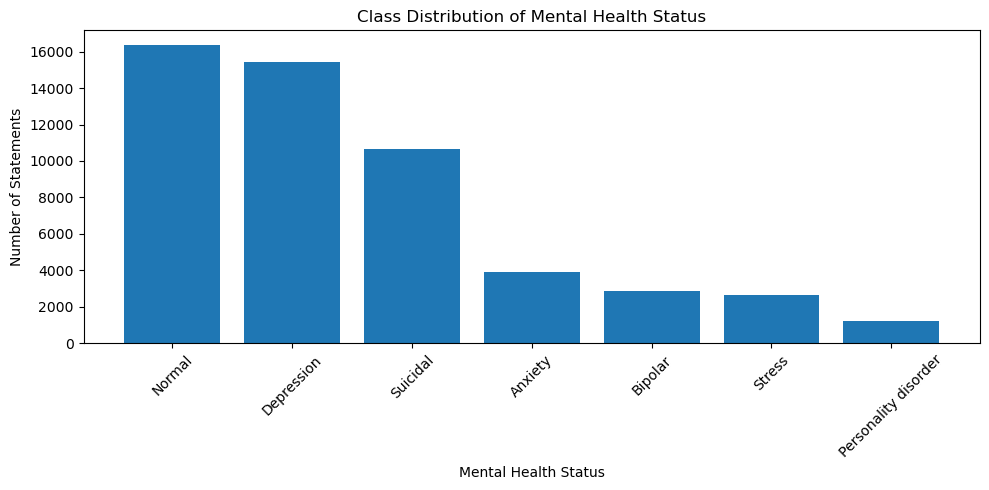

In [91]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts["Mental Health Status"], class_counts["Count"])
plt.title("Class Distribution of Mental Health Status")
plt.xlabel("Mental Health Status")
plt.ylabel("Number of Statements")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.7 Text Length Analysis

In [93]:
eda_df = df.copy()

eda_df["char_length"] = eda_df[text_col].astype(str).apply(len)
eda_df["word_length"] = eda_df[text_col].astype(str).apply(lambda x: len(x.split()))

eda_df[[text_col, label_col, "char_length", "word_length"]].head()

,statement,status,char_length,word_length
0,oh my gosh,Anxiety,10,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14
3,I've shifted my focus to something else but I'...,Anxiety,61,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14


In [94]:
text_length_summary = eda_df[["char_length", "word_length"]].describe().round(2)

text_length_summary

,char_length,word_length
count,53043.00,53043.00
mean,574.78,112.39
std,844.71,163.44
min,2.00,1.00
25%,77.00,15.00
50%,313.00,61.00
75%,748.00,147.50
max,32759.00,6300.00


In [97]:
length_percentiles = pd.DataFrame({
    "Percentile": ["50%", "75%", "90%", "95%", "99%"],
    "Word Length": [
        np.percentile(eda_df["word_length"], 50),
        np.percentile(eda_df["word_length"], 75),
        np.percentile(eda_df["word_length"], 90),
        np.percentile(eda_df["word_length"], 95),
        np.percentile(eda_df["word_length"], 99)
    ]
})

length_percentiles["Word Length"] = length_percentiles["Word Length"].round(0).astype(int)

length_percentiles

,Percentile,Word Length
0,50%,61
1,75%,148
2,90%,277
3,95%,394
4,99%,732


In [98]:
length_by_class = eda_df.groupby(label_col).agg(
    count=(text_col, "count"),
    average_word_length=("word_length", "mean"),
    median_word_length=("word_length", "median"),
    max_word_length=("word_length", "max"),
    average_char_length=("char_length", "mean")
).reset_index()

length_by_class["average_word_length"] = length_by_class["average_word_length"].round(2)
length_by_class["average_char_length"] = length_by_class["average_char_length"].round(2)

length_by_class

,status,count,average_word_length,median_word_length,max_word_length,average_char_length
0,Anxiety,3841,142.11,101.0,1592,755.47
1,Bipolar,2777,170.11,125.0,4804,913.30
2,Depression,15404,168.02,113.0,4239,844.03
3,Normal,16343,17.24,10.0,255,90.20
4,Personality disorder,1077,160.93,117.0,5419,858.26
5,Stress,2587,111.10,85.0,1606,594.79
6,Suicidal,10652,146.43,92.0,6300,734.90


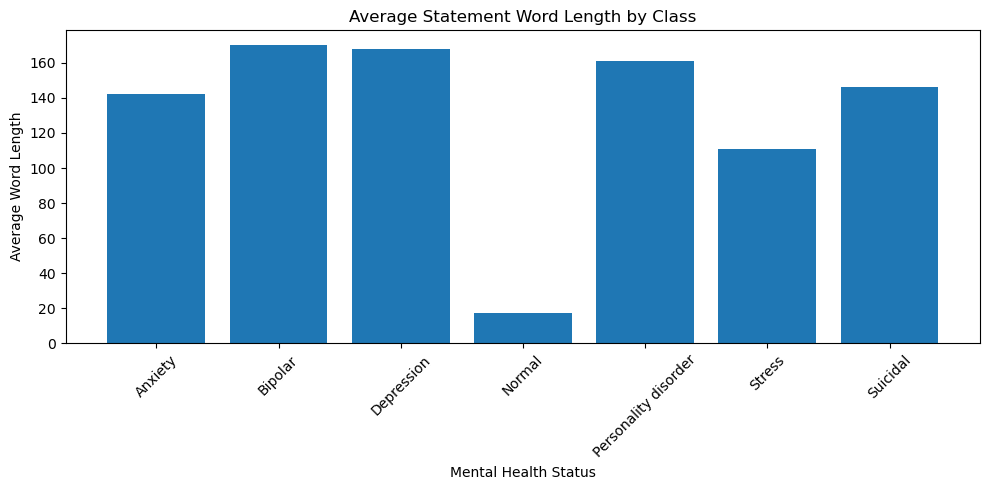

In [103]:
plt.figure(figsize=(10, 5))
plt.bar(length_by_class[label_col], length_by_class["average_word_length"])
plt.title("Average Statement Word Length by Class")
plt.xlabel("Mental Health Status")
plt.ylabel("Average Word Length")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5.8 Word Frequency Analysis

In [104]:
def basic_eda_normalize(text):
    """
    Temporary light text normalization for EDA only.
    This does not permanently preprocess the dataset.
    """
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

eda_df["eda_text"] = eda_df[text_col].apply(basic_eda_normalize)

eda_df[[text_col, "eda_text"]].head()

,statement,eda_text
0,oh my gosh,oh my gosh
1,"trouble sleeping, confused mind, restless hear...",trouble sleeping confused mind restless heart ...
2,"All wrong, back off dear, forward doubt. Stay ...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,ive shifted my focus to something else but im ...
4,"I'm restless and restless, it's been a month n...",im restless and restless its been a month now ...


In [108]:
all_words = " ".join(eda_df["eda_text"].dropna()).split()

word_counts = Counter(all_words)

common_words = pd.DataFrame(
    word_counts.most_common(30),
    columns=["Word", "Frequency"]
)

common_words

,Word,Frequency
0,i,401449
1,to,197450
2,and,175482
3,the,126743
4,my,119452
5,a,117750
6,it,86266
7,of,84898
8,not,76283
9,me,72253


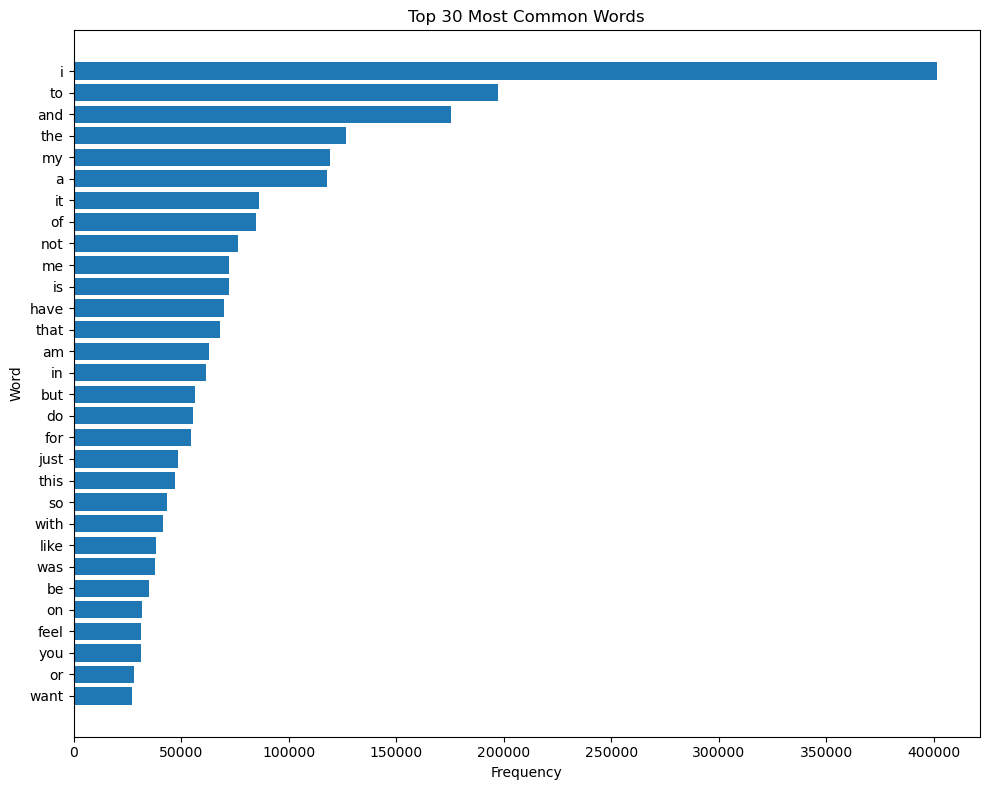

In [109]:
plt.figure(figsize=(10, 8))
plt.barh(common_words["Word"][::-1], common_words["Frequency"][::-1])
plt.title("Top 30 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## 5.9 N-gram Analysis

In [110]:
def get_top_ngrams(text_series, ngram_range=(2, 2), top_n=20):
    vectorizer = CountVectorizer(
        ngram_range=ngram_range,
        stop_words="english",
        max_features=5000
    )
    
    ngram_matrix = vectorizer.fit_transform(text_series.dropna())
    ngram_counts = np.asarray(ngram_matrix.sum(axis=0)).flatten()
    ngram_features = vectorizer.get_feature_names_out()
    
    ngram_df = pd.DataFrame({
        "N-gram": ngram_features,
        "Frequency": ngram_counts
    }).sort_values(by="Frequency", ascending=False).head(top_n)
    
    return ngram_df

### Top bigrams

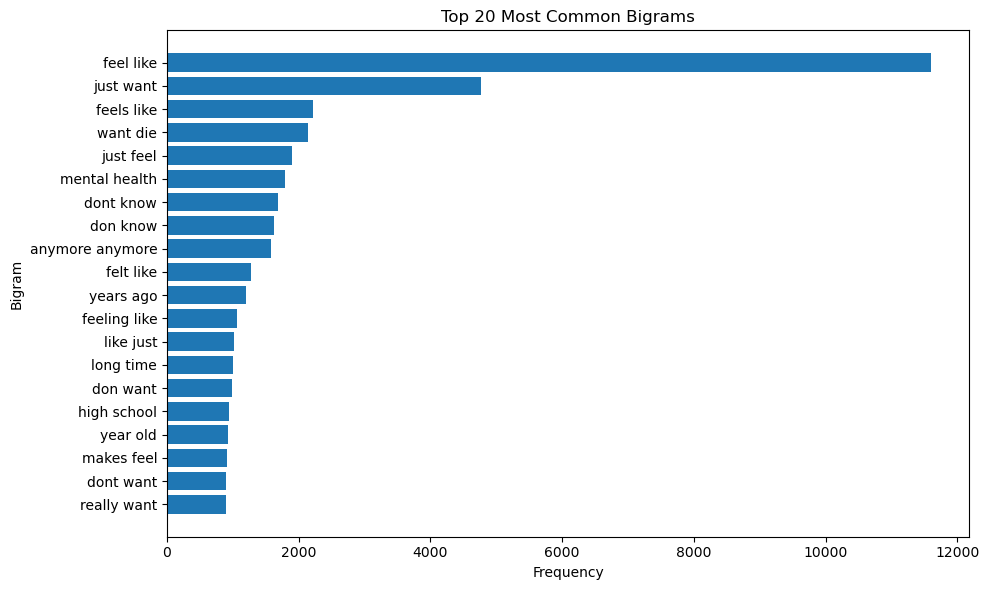

In [112]:
plt.figure(figsize=(10, 6))
plt.barh(top_bigrams["N-gram"][::-1], top_bigrams["Frequency"][::-1])
plt.title("Top 20 Most Common Bigrams")
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.tight_layout()
plt.show()

### Top trigrams

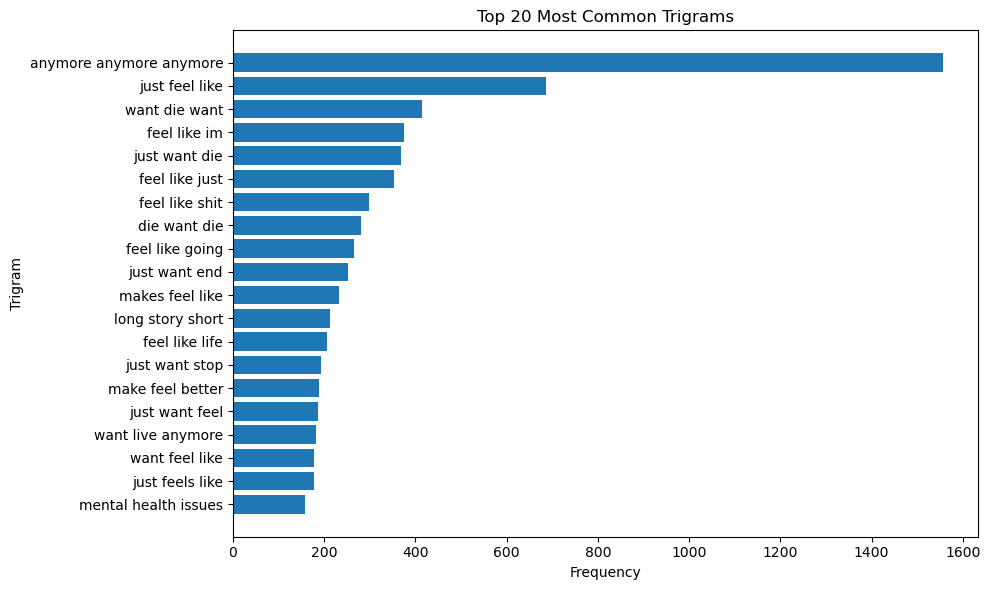

In [114]:
plt.figure(figsize=(10, 6))
plt.barh(top_trigrams["N-gram"][::-1], top_trigrams["Frequency"][::-1])
plt.title("Top 20 Most Common Trigrams")
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.tight_layout()
plt.show()

## 5.10 Vocabulary Analysis

In [115]:
unique_words = set(all_words)

vocabulary_summary = pd.DataFrame({
    "Metric": [
        "Total number of words",
        "Total unique words",
        "Vocabulary richness ratio"
    ],
    "Value": [
        len(all_words),
        len(unique_words),
        round(len(unique_words) / len(all_words), 4)
    ]
})

vocabulary_summary

,Metric,Value
0,Total number of words,5917695.000
1,Total unique words,77113.000
2,Vocabulary richness ratio,0.013


### Vocabulary size by class

In [116]:
vocab_by_class = []

for label in eda_df[label_col].dropna().unique():
    class_text = " ".join(
        eda_df[eda_df[label_col] == label]["eda_text"].dropna()
    )
    
    class_words = class_text.split()
    class_unique_words = set(class_words)
    
    vocab_by_class.append({
        "Mental Health Status": label,
        "Total Words": len(class_words),
        "Unique Words": len(class_unique_words),
        "Vocabulary Richness Ratio": round(len(class_unique_words) / len(class_words), 4) if len(class_words) > 0 else 0
    })

vocab_by_class_df = pd.DataFrame(vocab_by_class).sort_values(
    by="Unique Words",
    ascending=False
)

vocab_by_class_df

,Mental Health Status,Total Words,Unique Words,Vocabulary Richness Ratio
2,Depression,2573059,41427,0.0161
3,Suicidal,1549915,30897,0.0199
1,Normal,278318,23369,0.0840
0,Anxiety,546616,16318,0.0299
5,Bipolar,484704,15679,0.0323
4,Stress,293014,11956,0.0408
6,Personality disorder,192069,8607,0.0448


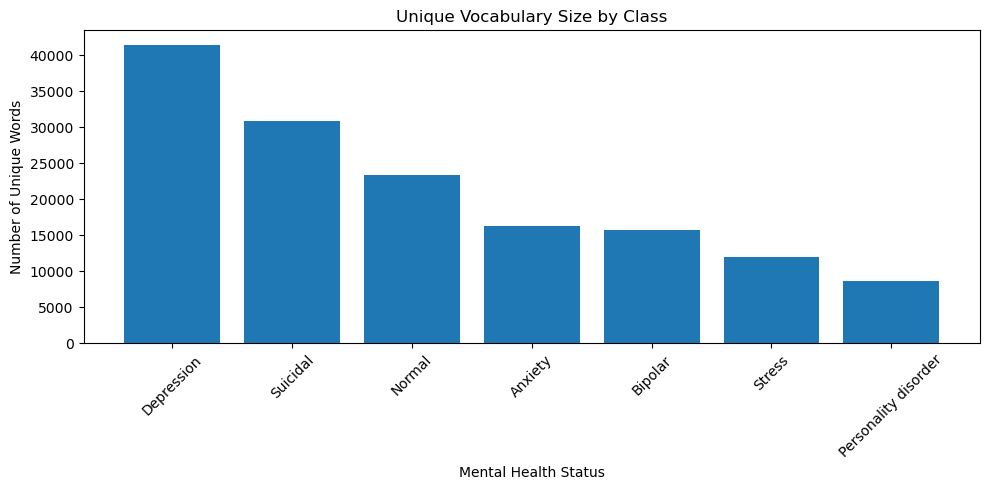

In [117]:
plt.figure(figsize=(10, 5))
plt.bar(vocab_by_class_df["Mental Health Status"], vocab_by_class_df["Unique Words"])
plt.title("Unique Vocabulary Size by Class")
plt.xlabel("Mental Health Status")
plt.ylabel("Number of Unique Words")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Most common words per class

In [121]:
top_words_per_class = {}

for label in eda_df[label_col].dropna().unique():
    class_words = " ".join(
        eda_df[eda_df[label_col] == label]["eda_text"].dropna()
    ).split()
    
    class_word_counts = Counter(class_words)
    
    top_words_per_class[label] = pd.DataFrame(
        class_word_counts.most_common(5),
        columns=["Word", "Frequency"]
    )

# Display top words for each class
for label, table in top_words_per_class.items():
    print("\n===================================")
    print("Class:", label)
    print("===================================")
    display(table)
    
    


Class: Anxiety


,Word,Frequency
0,i,28411
1,and,17269
2,to,14648
3,the,13321
4,a,12807



Class: Normal


,Word,Frequency
0,i,9758
1,to,8671
2,the,8100
3,a,6001
4,and,5265



Class: Depression


...

,Word,Frequency
0,i,14472
1,and,9994
2,to,9821
3,the,7012
4,a,6375



Class: Bipolar


,Word,Frequency
0,i,26411
1,and,15667
2,to,14474
3,the,11051
4,a,10677



Class: Personality disorder


,Word,Frequency
0,i,10639
1,to,6451
2,and,5709
3,the,3998
4,a,3736


## 5.11 EDA Summary Tables

In [122]:
eda_summary = pd.DataFrame({
    "EDA Area": [
        "Dataset size",
        "Missing values",
        "Duplicate rows",
        "Duplicate statements",
        "Number of classes",
        "Average word length",
        "Median word length",
        "Maximum word length",
        "Total unique vocabulary"
    ],
    "Result": [
        f"{df.shape[0]} rows and {df.shape[1]} columns",
        int(df.isnull().sum().sum()),
        int(total_duplicate_rows),
        int(duplicate_statements),
        df[label_col].nunique(),
        round(eda_df["word_length"].mean(), 2),
        round(eda_df["word_length"].median(), 2),
        int(eda_df["word_length"].max()),
        len(unique_words)
    ]
})

eda_summary

,EDA Area,Result
0,Dataset size,53043 rows and 3 columns
1,Missing values,362
2,Duplicate rows,0
3,Duplicate statements,1969
4,Number of classes,7
5,Average word length,112.39
6,Median word length,61.0
7,Maximum word length,6300
8,Total unique vocabulary,77113
